In [3]:
import math
import sys

import numpy as np
import matplotlib.pyplot as plt


#### Classification of the logistic map with an ESN

Let's make an ESN to classify the logistic map, which is a representative one-dimensional discrete dynamical system.
The logistic map is represented by the following equation:

$$
\begin{align*}
x[k+1] = a x[k] (1 - x[k])
.\end{align*}
$$

- $k \in \mathbb{Z} $: Discrete time
- $x[k] \in \mathbb{R} $: System state
- $a \in \mathbb{R} $: Parameter (constant), our classification

The logistic map is a useful sequence to analyze because it can be chaotic (for a > 3.56995) or not chaotic, while being simple to generate.

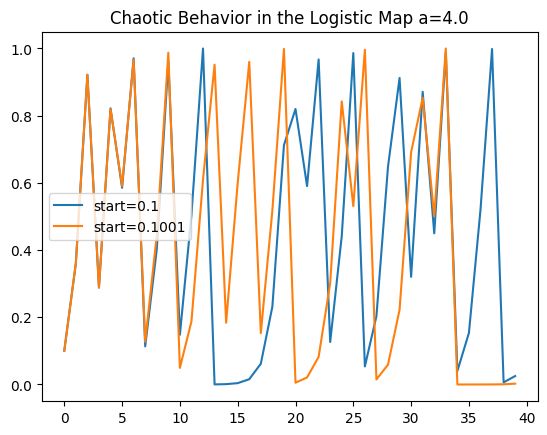

In [4]:
def logistic_func(z, a=4.0):
    z_dot = a * z * (1 - z)
    return z_dot

def generate_logistic_series(start=0.1,a=4.0,length=100):
    series = [start]
    for _ in range(length - 1):
        next_value = logistic_func(series[-1], a)
        series.append(next_value)
    return series

a=4.0
x_series = generate_logistic_series(0.1,a,40)
y_series = generate_logistic_series(0.1001,a,40)


plt.plot(x_series, label="start=0.1")
plt.plot(y_series, label="start=0.1001")
plt.title("Chaotic Behavior in the Logistic Map a="+ str(a))
plt.legend()
plt.show()



The logistic map has the following attractors:
- Fixed point, for the range $ a < 3$
- Periodic orbits, for the range $3 \leq a \leq 3.569...$ (with period-doubling bifurcations in between).
- Chaos, for the range $3.569 < a$ (with some regions having 3-period orbits, etc.).

We will train an ESN to predict the chaotic case. The above graph shows how initally very similar inputs can lead to very different outputs. Due to rounding error, the series starting at 0.1001 eventually collapses to 0.

The internal state and output are defined as follows:

$$
\begin{align*}
x[k+1] &= (1-a)~x[k] + a~{f}(W^\mathrm{rec}x[k] + W^\mathrm{in} u[k+1]) \\
\hat{y}[k] &= {W^\mathrm{out}}^\top [1 ; x[k]] \\
&= {W^\mathrm{out}}^\top {[1 \quad x_1[k] \quad \cdots \quad x_{N}[k]]}^\top \\
&= W^\mathrm{out}_0 + \sum_{i=1}^{N} W^\mathrm{out}_i x_{i}[k]
,\end{align*}
$$

with activation function e.g., $f(x)=[\tanh(x_1[k]) \quad \cdots \quad \tanh(x_N[k])]^\top$.

The code used follows the construction of an ESN from the RC Bootcamp https://rc-bootcamp.github.io/.

In [5]:
class Module(object):
    def __init__(self, *_args, seed=None, rnd=None, dtype=np.float64, **_kwargs):
        if rnd is None:
            self.rnd = np.random.default_rng(seed)
        else:
            self.rnd = rnd
        self.dtype = dtype


class Linear(Module):
    def __init__(self, input_dim: int, output_dim: int, bound: float = None, bias: float = 0.0, **kwargs):
        """
        Linear model

        Args:
            input_dim (int): input dimension
            output_dim (int): output dimension
            bound (float, optional): sampling scale for weight. Defaults to None.
            bias (float, optional): sampling scale for bias. Defaults to 0.0.
        """
        super(Linear, self).__init__(**kwargs)
        self.input_dim = input_dim
        self.output_dim = output_dim
        if bound is None:
            bound = math.sqrt(1 / input_dim)
        self.weight = self.rnd.uniform(-bound, bound, (output_dim, input_dim)).astype(self.dtype)
        self.bias = self.rnd.uniform(-bias, bias, (output_dim,)).astype(self.dtype)

    def __call__(self, x: np.ndarray):
        x = np.asarray(x)
        out = np.matmul(x, self.weight.swapaxes(-1, -2)) + self.bias
        return out


def solution(input_dim, output_dim, seed, bound, bias, mat):
    lin = Linear(input_dim, output_dim, bound=bound, bias=bias, seed=seed)
    return lin(mat)

In [6]:
from scipy.sparse.linalg import ArpackNoConvergence, eigs


class ESN(Module):
    def __init__(
        self,
        dim: int,
        sr: float = 1.0,
        f=np.tanh,
        a: float | None = None,
        p: float = 1.0,
        init_state: np.ndarray | None = None,
        normalize: bool = True,
        **kwargs,
    ):
        """
        Echo state network [Jaeger, H. (2001). Bonn, Germany:
        German National Research Center for Information Technology GMD Technical Report, 148(34), 13.]

        Args:
            dim (int): number of the ESN nodes
            sr (float, optional): spectral radius. Defaults to 1.0.
            f (callable, optional): activation function. Defaults to np.tanh.
            a (float | None, optional): leaky rate. Defaults to None.
            p (float, optional): density of connection matrix. Defaults to 1.0.
            init_state (np.ndarray | None, optional): initial states. Defaults to None.
            normalize (bool, optional): decide if normalizing connection matrix. Defaults to True.
        """
        super(ESN, self).__init__(**kwargs)
        self.dim = dim
        self.sr = sr
        self.f = f
        self.a = a
        self.p = p
        if init_state is None:
            self.x_init = np.zeros(dim, dtype=self.dtype)
        else:
            self.x_init = np.array(init_state, dtype=self.dtype)
        self.x = np.array(self.x_init)
        # Generating normalized sparse matrix
        while True:
            try:
                self.weight = self.rnd.normal(size=(self.dim, self.dim)).astype(self.dtype)
                if self.p < 1.0:  # Sparse matrix
                    # Implement sparse matrix with density `self.p`.
                    w_con = np.full((dim * dim,), False)
                    w_con[: int(dim * dim * self.p)] = True
                    w_con = w_con.reshape((dim, dim))
                    self.rnd.shuffle(w_con)
                    self.weight = self.weight * w_con

                if normalize:
                    # Calculate `spectral_radius`. Use `eigs` and specify `v0` parameter as `np.ones(self.dim)` to ensure the reproducibility.
                    eigen_values = eigs(self.weight, return_eigenvectors=False, k=1, which="LM", v0=np.ones(self.dim))
                    spectral_radius = max(abs(eigen_values))
                    self.weight = self.weight / spectral_radius  # Normalize the weight matrix.
                break
            except ArpackNoConvergence:
                continue

    def __call__(self, x: np.ndarray, v: np.ndarray | None = None):
        x_next = self.sr * np.matmul(x, self.weight.swapaxes(-1, -2))  # Calculate the next state `x_next`.
        if v is not None:
            x_next += v  # Add the input `v` if it is given.
        x_next = self.f(x_next)  # Apply the activation function.
        if self.a is None:
            return x_next
        else:
            return (1 - self.a) * x + self.a * x_next

    def step(self, v: np.ndarray | None = None):
        self.x = self(self.x, v)


def solution(dim, sr, seed, xmat, vmat):
    net = ESN(dim, sr=sr, f=np.tanh, seed=seed)
    return net(xmat, v=vmat)



In [7]:
class LRReadout(Linear):
    def train(self, x: np.ndarray, y: np.ndarray):
        assert (x.ndim == 2) and (x.shape[-1] == self.input_dim)
        assert (y.ndim == 2) and (y.shape[-1] == self.output_dim)
        # Calculate the optimal weight and bias.
        x_biased = np.ones((x.shape[0], x.shape[1] + 1), dtype=self.dtype)
        x_biased[:, 1:] = x
        sol, _residuals, _rank, _s = np.linalg.lstsq(x_biased, y, rcond=None)
        self.weight[:] = sol[1:].T
        self.bias[:] = sol[0]
        return self.weight, self.bias


def solution(dim_in, dim_out, x_train, y_train, x_eval):
    readout = LRReadout(dim_in, dim_out)
    readout.train(x_train, y_train)
    return readout(x_eval)

In [8]:
def calc_nrmse(y, yhat):
    mse = y - yhat
    mse = (mse * mse).mean(axis=0)
    var = y.var(axis=0)
    return (mse / var) ** 0.5


This time, lets try to classify the logistic maps. In order to do this, we run the ESN on the logistic map for a small number of steps for multiple starting inputs and parameters a. We then take the output of the reservoir and use it to predict the value of a with linear regression.

NRMSE = [0.09605475]
% correct = 0.9119


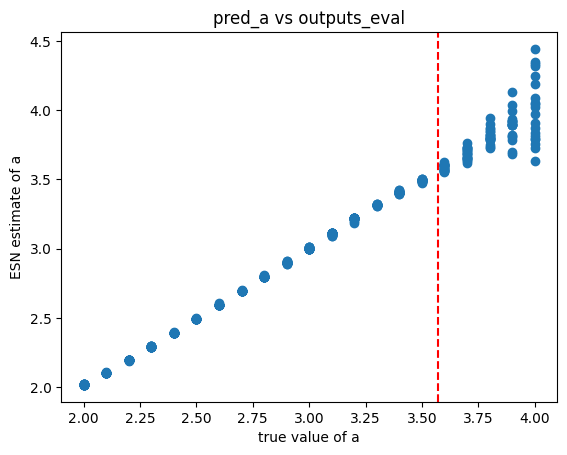

In [43]:
rnd = np.random.default_rng(1234)
dim_esn, rho, sigma = 100, 0.7, 0.1 #some reasonable values that line up with earlier results on ESN prediction
series_length = 20
n_classes = 21
n_train = 50
n_eval = 20
classes = np.linspace(2,4,n_classes) #all values of a we will use
ser = np.zeros(series_length) #could do locally in the for loop maybe
true_a = np.repeat(classes, n_train).reshape(-1, 1) #the true value of a for each
x_init = np.zeros((dim_esn,))
w_in = Linear(1, dim_esn, bound=sigma, bias=0.0, rnd=rnd)
net = ESN(dim_esn, sr=rho, f=np.tanh, init_state=x_init, rnd=rnd)
w_out = LRReadout(dim_esn, 1)
outputs = np.zeros((n_classes * n_train, dim_esn)) #stores final states

for j in range(n_classes):
  c=classes[j]
  for i in range(n_train):
    ser = np.array(generate_logistic_series(rnd.random(),c,series_length)).reshape(-1, 1)
    x = x_init
    for idx in range(series_length):
      x = net(x, w_in(ser[idx]))
    outputs[i+j*n_train] = x

w_out.train(outputs,true_a) #training complete

outputs_eval = np.zeros((n_classes * n_eval, dim_esn))
eval_a = np.repeat(classes, n_eval).reshape(-1, 1)
for j in range(n_classes):
  c=classes[j]
  for i in range(n_eval):
    ser = np.array(generate_logistic_series(rnd.random(),c,series_length)).reshape(-1, 1)
    x = x_init
    for idx in range(series_length):
      x = net(x, w_in(ser[idx]))
    outputs_eval[i+j*n_eval] = x

pred_a = w_out(outputs_eval)
nrmse=calc_nrmse(eval_a,pred_a)
print(f"NRMSE = {nrmse}")

true_class = np.round((eval_a - eval_a.min()) / (eval_a.max() - eval_a.min()) * (n_classes - 1))
pred_class = np.round((pred_a - eval_a.min()) / (eval_a.max() - eval_a.min()) * (n_classes - 1))

accuracy = np.mean(pred_class == true_class)
print(f"% correct = {accuracy:.4f}")

plt.scatter(eval_a, pred_a)
plt.xlabel("true value of a")
plt.ylabel("ESN estimate of a")
plt.axvline(x=3.56995, color='r', linestyle='--', label='3.56995')
plt.title("pred_a vs outputs_eval")
plt.show()




The model predicts much worse past the point after which the logistic map becomes chaotic